### QRAM Implementation 

Implementing the following QRAM

| Key | Value |
|-----|-------|
| 000 | 0111  |
| 001 | 0011  |
| 010 | 1101  |
| 011 | 0000  |
| 100 | 1111  |
| 101 | 0100  |
| 110 | 1100  |
| 111 | 0101  |

The QRAM is implemented for a fixed key/value size (3 key qubits, 4 value qubits),
matching the table above. The same construction generalizes to any number of
key and value qubits without changing the underlying logic.

In [10]:
from qiskit import QuantumCircuit
from qiskit.circuit import QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

In [11]:
# QRAM definition
qram_definition = {
    '000': '0111',
    '001': '0011',
    '010': '1101',
    '011': '0000',
    '100': '1111',
    '101': '0100',
    '110': '1100',
    '111': '0101'
}

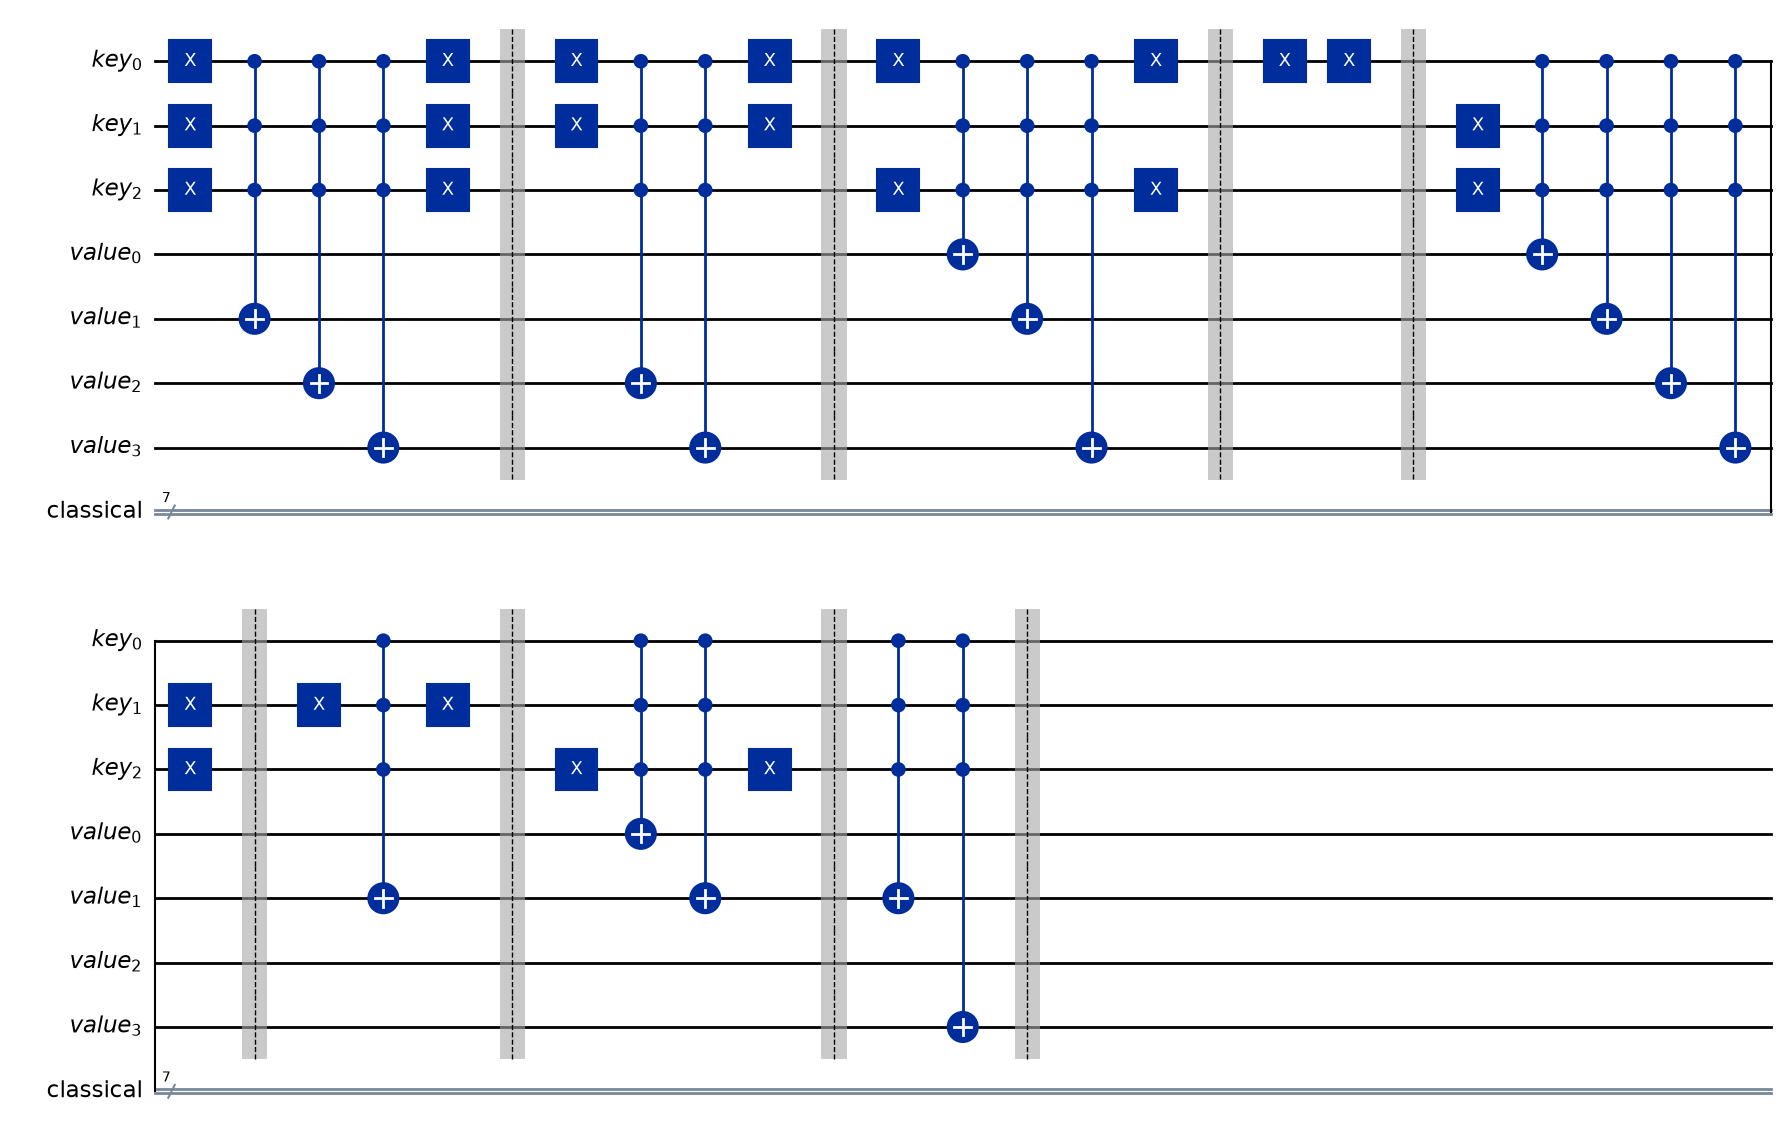

In [12]:
key_qubits = len(list(qram_definition.keys())[0])
value_qubits = len(list(qram_definition.values())[0])

key_register = QuantumRegister(key_qubits, "key")
value_register = QuantumRegister(value_qubits, "value")
classical_register = ClassicalRegister(key_qubits+value_qubits, 'classical')

qc = QuantumCircuit(key_register, value_register, classical_register)


# For each key-value pair, build a block that:
# 1) flips the key register's 0-bits to 1, so the register reads all-1s
#    exactly when the input matches this key (turns key into a single AND condition)
# 2) for every '1' bit in the value, applies a multi-controlled-X gate
#    controlled on all key qubits, writing that bit into the value register
#    only when the key register matches
# 3) flips the same 0-bits back, restoring the key register to its original state
# A barrier separates each key's block for clarity in the circuit diagram


for keys, values in qram_definition.items():
    for idx_key, key in enumerate(keys):
        if key == '0':
            qc.x(key_register[idx_key])
    for idx_value, value in enumerate(values):
        if value == '1':
            qc.mcx(key_register, value_register[idx_value])
    #this loop to restart to 0
    for idx_key, key in enumerate(keys):
        if key == '0':
            qc.x(key_register[idx_key])
    qc.barrier()

qc.draw(output='mpl')


In [13]:
# Verification: for each possible key, prepare a circuit where that key is
# set as input, run the QRAM circuit, and measure both registers.
# If the QRAM was built correctly, the simulator should return the
# corresponding value with probability 1 (a single outcome across all shots).

sim = AerSimulator()
shots = 1024

for key in qram_definition:

  # Build a small circuit that sets the input register to this key
  # (X-gate on every '1' bit) before feeding it into the QRAM circuit

  init_circuit = QuantumCircuit(key_qubits+value_qubits, key_qubits+value_qubits)
  for idx_qubit, qubit in enumerate(key):
    if qubit == '1':
      init_circuit.x(idx_qubit)
  # Prepend the key-initialization circuit to the QRAM circuit
  qc_copy_to_test = qc.compose(init_circuit, front=True)

  # measure
  for idx_key in range(len(key)): qc_copy_to_test.measure(key_register[idx_key], classical_register[idx_key])
  for idx_value in range(len(qram_definition[key])): qc_copy_to_test.measure(value_register[idx_value], classical_register[len(key)+idx_value])

  job = sim.run(qc_copy_to_test, shots=shots, optimization_level=0)
  counts = job.result().get_counts()

  # Most probable measured outcome (qiskit returns bitstrings reversed, hence [::-1])
  result = max(counts, key=counts.get)[::-1]

  if result[len(key):] == qram_definition[key]:
    print('🎉 Case for key', key, 'is correct!!')
    print()
  else:
    print('💥 WRONG! Case for key', key, 'is NOT correct')
    print('Circuit measure is', result[len(key):], 'and correct value is', qram_definition[key])
    print()


🎉 Case for key 000 is correct!!

🎉 Case for key 001 is correct!!

🎉 Case for key 010 is correct!!

🎉 Case for key 011 is correct!!

🎉 Case for key 100 is correct!!

🎉 Case for key 101 is correct!!

🎉 Case for key 110 is correct!!

🎉 Case for key 111 is correct!!

